In [1]:
# import mediapipe as mp
# import numpy as np
# import sys
# import os
# from decord import VideoReader, cpu
# import pickle
import torch
import torch.nn as nn
# from torch.utils.data import DataLoader
import yaml
# from collections import OrderedDict
# from lib.utils.model_utils import count_params, import_class
from torchvision.transforms import v2
from lib.data.dataset import CustomVideoDataset
from lib.utils.transforms import GetPoses_YOLO
from lib.utils.objects import ArgClass

In [30]:
# Get arg file
with open('./config/custom_pose/train_joint.yaml', 'r') as file:
    yaml_arg = yaml.safe_load(file)

arg = ArgClass(arg=yaml_arg)

# # Get the annotation file
# with open(arg.dataloader['label_path'], 'r') as file:
#     ann_file = yaml.safe_load(file)

Create the dataset, later we'll create the dataloader

In [31]:
from ultralytics import YOLO
# Create pose detector
detector = YOLO('yolov8n-pose.pt')
transforms = v2.Compose([
    v2.Resize(size=(384,640)),
    v2.ToDtype(torch.float32),
    v2.ToTensor(),
    GetPoses_YOLO(detector=detector, max_frames=300, num_joints=17)
    ])
dataset = CustomVideoDataset(arg, transforms=transforms)

c:\Users\ldezoetegrundy\.local\share\mamba\envs\torch_env\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


FileNotFoundError: [Errno 2] No such file or directory: '../Datasets/UCF-101/ucf101_annotations.yaml'

### Data input shape

data_path: the path to '.npy' data, the shape of data should be (N, C, T, V, M)

N (name/batch)

C (channels (x,y,score))

T (frame)

V (joint)

M (person)

Get the config arguments

In [32]:
from model import load_model
skel_model = load_model(arg)
skel_model.load_model()

	Output device: 0
	Model total number of params: 2999801


Get the model summary

In [33]:
from torchsummary import summary

model = skel_model.model.to('cuda:0')
summary(model, (3, 300, 17, 2))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
       BatchNorm1d-1             [-1, 102, 300]             204
            Conv2d-2          [-1, 96, 300, 17]           2,400
       BatchNorm2d-3          [-1, 96, 300, 17]             192
              ReLU-4          [-1, 96, 300, 17]               0
               MLP-5          [-1, 96, 300, 17]               0
MultiScale_GraphConv-6          [-1, 96, 300, 17]               0
            Conv2d-7          [-1, 16, 300, 17]           1,552
       BatchNorm2d-8          [-1, 16, 300, 17]              32
              ReLU-9          [-1, 16, 300, 17]               0
           Conv2d-10          [-1, 16, 300, 17]             784
      BatchNorm2d-11          [-1, 16, 300, 17]              32
     TemporalConv-12          [-1, 16, 300, 17]               0
           Conv2d-13          [-1, 16, 300, 17]           1,552
      BatchNorm2d-14          [-1, 16

In [63]:
param_groups = {'params': []}
for name, params in model.named_parameters():
    param_groups['params'].append(params)
params = list({'other': param_groups}.values())

In [65]:
from torch import optim
# Create the optimiser
optimiser = optim.SGD(
                params,
                lr=arg.base_lr,
                momentum=0.9,
                nesterov=arg.nesterov,
                weight_decay=arg.weight_decay)
scheduler1 = optim.lr_scheduler.LinearLR(optimiser, start_factor=0.5, total_iters=10)
scheduler2 = optim.lr_scheduler.ExponentialLR(optimiser, gamma=0.93)
scheduler = optim.lr_scheduler.SequentialLR(optimiser, schedulers=[scheduler1, scheduler2], milestones=[10])

In [71]:
checkpoint_file = 'new_checkpoint.pt'
epoch = 1
results={'best_loss': 0}
if checkpoint_file is not None:
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimiser_state_dict': optimiser.state_dict(),
        'results' : results
        }, checkpoint_file)

In [72]:
checkpoint = torch.load('new_checkpoint.pt')
print(checkpoint['epoch'])

1


## Inference!

In [9]:
import torch.optim as optim
from collections import defaultdict
from torch.utils.data import DataLoader

# Create the dataloader
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)

# Get the parameters to optimise
param_groups = defaultdict(list)
for name, params in skel_model.model.named_parameters():
    param_groups['other'].append(params)
optim_param_groups = {
    'other': {'params': param_groups['other']}
}
params = list(optim_param_groups.values())

# Create the optimiser
optimizer = optim.SGD(
                params,
                lr=0.1,
                momentum=0.9,
                nesterov=False,
                weight_decay=0.0005)

loss = nn.CrossEntropyLoss()

In [7]:
classes = {}
for elem, key in enumerate(dict.fromkeys(key.split('_')[0] for key in ann_file.keys())):
    classes[key] = elem

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd

y_pred = []
y_true = []

# iterate over test data
for inputs, labels in train_dataloader:
        output = model(inputs) # Feed Network

        output = (torch.max(torch.exp(output), 1)[1]).data.cpu().numpy()
        y_pred.extend(output) # Save Prediction
        
        labels = labels.data.cpu().numpy()
        y_true.extend(labels) # Save Truth

# constant for classes
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Build confusion matrix
cf_matrix = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cf_matrix / np.sum(cf_matrix, axis=1)[:, None], index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)
plt.savefig('output.png')

## Plotting small versus large model accuracy!

In [67]:
import matplotlib.pyplot as plt

with open('logs/train_warmup-exp0.93_SMALL.txt', 'r') as file:
    txt_small = file.read()

with open('logs/train_warmup-exp0.93_SAVE.txt', 'r') as file:
    txt_large = file.read()

def get_test_acc(text_string):
    accs = {}
    epoch = 0
    for row in text_string.split('\n'):
        if 'test:' in row:
            accs[epoch] = float(row.split(': ')[-1])*100
            epoch+=1
    return accs

print(txt_small.split('\n'))

['### Libraries loaded', '### Arguments loaded', '\tOutput device: 0', '\tModel total number of params: 823777', '### Model created', "{'start_factor': 0.5, 'end_factor': 1.0, 'total_iters': 10, 'optimizer': SGD (", 'Parameter Group 0', '    dampening: 0', '    differentiable: False', '    foreach: None', '    fused: None', '    initial_lr: 0.5', '    lr: 0.25', '    maximize: False', '    momentum: 0.9', '    nesterov: True', '    weight_decay: 0.0003', "), 'base_lrs': [0.5], 'last_epoch': 0, 'verbose': False, '_step_count': 1, '_get_lr_called_within_step': False, '_last_lr': [0.25]}", "{'gamma': 0.93, 'optimizer': SGD (", 'Parameter Group 0', '    dampening: 0', '    differentiable: False', '    foreach: None', '    fused: None', '    initial_lr: 0.5', '    lr: 0.25', '    maximize: False', '    momentum: 0.9', '    nesterov: True', '    weight_decay: 0.0003', "), 'base_lrs': [0.5], 'last_epoch': -1, 'verbose': False, '_step_count': 1, '_get_lr_called_within_step': False, '_last_lr':

In [109]:
# Accuracy
small_accs = get_test_acc(txt_small)
large_accs = get_test_acc(txt_large)

# Training time per epoch
small_time = [float(elem)/60 for elem in ((txt_small.split('\'total time\': ')[-1]).split('train loss')[0][1:-4]).split(', ')]
large_time = [float(elem)/60 for elem in ((txt_large.split('\'total time\': ')[-1]).split('train loss')[0][1:-4]).split(', ')]

# Learning rate
lr = [float(elem) for elem in ((txt_small.split('\'lr\': ')[-1]).split('test loss')[0][1:-4]).split(', ')]

In [110]:
print(f'Max small model accuracy (joints only): {max(small_accs.values()):0.2f}%')
print(f'Max large model accuracy (joints only): {max(large_accs.values()):0.2f}%')

print(f'Total training time small model: {max(small_time):0.2f} minutes')
print(f'Total training time large model: {max(large_time):0.2f} minutes')

Max small model accuracy (joints only): 83.82%
Max large model accuracy (joints only): 83.63%
Total training time small model: 2.79 minutes
Total training time large model: 4.46 minutes


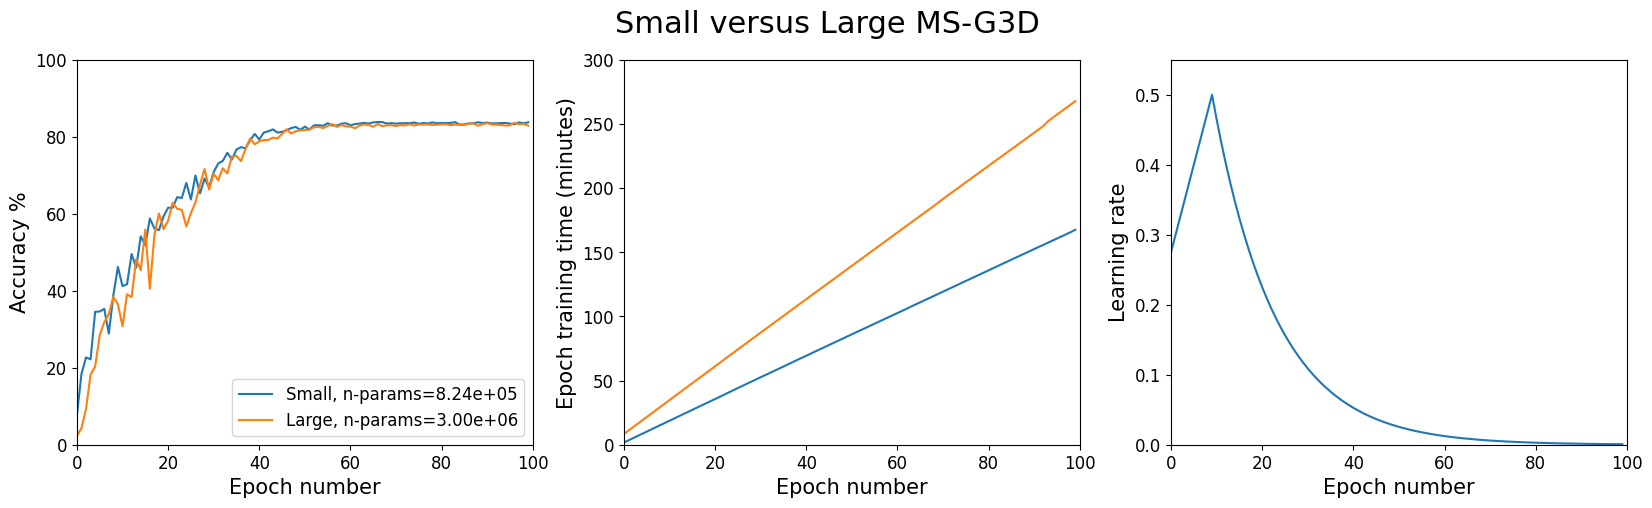

In [99]:
fig, axs = plt.subplots(1,3, figsize=(20,5))
# Plot test accuracy
axs[0].plot(small_accs.keys(), small_accs.values(), label=f'Small, n-params={823777:.2e}')
axs[0].plot(large_accs.keys(), large_accs.values(), label=f'Large, n-params={2999801:.2e}')
axs[0].set_ylabel('Accuracy %', fontsize=15)
axs[0].set_xlabel('Epoch number', fontsize=15)
axs[0].set_ylim(0,100)
axs[0].set_xlim(0,100)
axs[0].legend(loc=4, fontsize=12)

# Plot train time
axs[1].plot(small_time)
axs[1].plot(large_time)
axs[1].set_ylabel('Epoch training time (minutes)', fontsize=15)
axs[1].set_xlabel('Epoch number', fontsize=15)
axs[1].set_ylim(0,300)
axs[1].set_xlim(0,100)

# Plot learning rate 
axs[2].plot(lr)
axs[2].set_ylabel('Learning rate', fontsize=15)
axs[2].set_xlabel('Epoch number', fontsize=15)
axs[2].set_ylim(0,0.55)
axs[2].set_xlim(0,100)

for ax in axs:
    ax.yaxis.set_tick_params(labelsize=12)
    ax.xaxis.set_tick_params(labelsize=12)

fig.suptitle('Small versus Large MS-G3D', fontsize=22)
fig.savefig('small-large.png')